In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/forestfirev5/README.dataset.txt
/kaggle/input/forestfirev5/README.roboflow.txt
/kaggle/input/forestfirev5/data.yaml
/kaggle/input/forestfirev5/valid/labels/fire_0469_jpg.rf.0fd29f8fd32a4120d6f4424c66a9be26.txt
/kaggle/input/forestfirev5/valid/labels/fire_0227_jpg.rf.7a5d2400367749e1a9e8d4df72642271.txt
/kaggle/input/forestfirev5/valid/labels/abc126_jpg.rf.513b4309552b555a630cc0576d3fc157.txt
/kaggle/input/forestfirev5/valid/labels/abc146_jpg.rf.086b9e2a82c9c1af0b005e799680f912.txt
/kaggle/input/forestfirev5/valid/labels/fire_0650_jpg.rf.92e162c9d705a0058593fae36a738623.txt
/kaggle/input/forestfirev5/valid/labels/fire_0646_jpg.rf.33ac70ee72091710522d1a79a9813ad6.txt
/kaggle/input/forestfirev5/valid/labels/fire_0357_jpg.rf.bad172da50bf11e8be8106a1f84bd0d9.txt
/kaggle/input/forestfirev5/valid/labels/abc148_jpg.rf.029a83df5e26c39ad1a37f22192bdaa7.txt
/kaggle/input/forestfirev5/valid/labels/fire_0060_jpg.rf.cfdf1486636428d4e83b5799c0171345.txt
/kaggle/input/forestfirev5/valid/

In [2]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3

In [3]:
import yaml

# Load original data.yaml
yaml_path = "/kaggle/input/forestfirev5/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Fix the paths (use absolute paths for Kaggle)
data['train'] = '/kaggle/input/forestfirev5/train/images'
data['val'] = '/kaggle/input/forestfirev5/valid/images'
# Optional: test path if you want to evaluate
data['test'] = '/kaggle/input/forestfirev5/valid/images'

# Save the new YAML file to working directory
new_yaml_path = '/kaggle/working/data.yaml'

with open(new_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml saved at:", new_yaml_path)


Updated data.yaml saved at: /kaggle/working/data.yaml


In [4]:
import yaml

yaml_path = "/kaggle/working/data.yaml"

# Open and load the YAML file
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Print contents
print("YAML contents:")
print(data)

YAML contents:
{'names': ['fire', 'smoke'], 'nc': 2, 'roboflow': {'license': 'CC BY 4.0', 'project': 'forest-fire-detection-fis51', 'url': 'https://universe.roboflow.com/ghulam-ishaq-khan-institute-3qit1/forest-fire-detection-fis51/dataset/6', 'version': 6, 'workspace': 'ghulam-ishaq-khan-institute-3qit1'}, 'test': '/kaggle/input/forestfirev5/valid/images', 'train': '/kaggle/input/forestfirev5/train/images', 'val': '/kaggle/input/forestfirev5/valid/images'}


In [5]:
!yolo task=detect mode=train data=/kaggle/working/data.yaml model="yolov5nu.pt" epochs=100 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100%|███████████████████████████████████████| 5.31M/5.31M [00:00<00:00, 104MB/s]
Ultralytics 8.3.144 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01

In [6]:
from ultralytics import YOLO
from IPython.display import Image


image 1/1 /kaggle/input/forestfire13/fOREST-fire/images (2).jpg: 384x640 1 fire, 5 smokes, 49.1ms
Speed: 3.6ms preprocess, 49.1ms inference, 180.3ms postprocess per image at shape (1, 3, 384, 640)


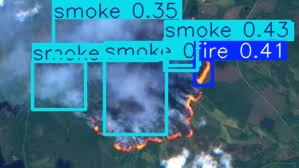

In [7]:
from ultralytics import YOLO

# Load the trained model
# IT IS STORED IN THE FOLLOWING VALIDATION FOLDER NAMED Validating runs/detect/train/weights/best.pt.
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

results = model("/kaggle/input/forestfire13/fOREST-fire/images (2).jpg")
results[0].show()

In [8]:
import pandas as pd

# Load the results CSV
df = pd.read_csv('/kaggle/working/runs/detect/train/results.csv')

# Display the first few rows
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,21.2542,2.34076,3.12841,2.09990,0.12140,0.18327,0.07659,0.02432,2.43503,2.95411,2.12649,0.000550,0.000550,0.000550
1,2,39.0807,2.19336,2.73873,1.99540,0.14171,0.18723,0.07623,0.02339,2.46160,3.40628,2.35220,0.001095,0.001095,0.001095
2,3,56.6182,2.18508,2.70461,2.00300,0.17828,0.18156,0.10296,0.03696,2.37067,3.02956,2.19289,0.001629,0.001629,0.001629
3,4,73.8380,2.16280,2.66840,1.97379,0.23599,0.17071,0.13293,0.04707,2.23563,2.80740,2.05115,0.001617,0.001617,0.001617
4,5,91.9589,2.13224,2.61387,1.95311,0.20173,0.26105,0.14996,0.05138,2.25382,2.88067,2.09402,0.001601,0.001601,0.001601


F1 Curve:


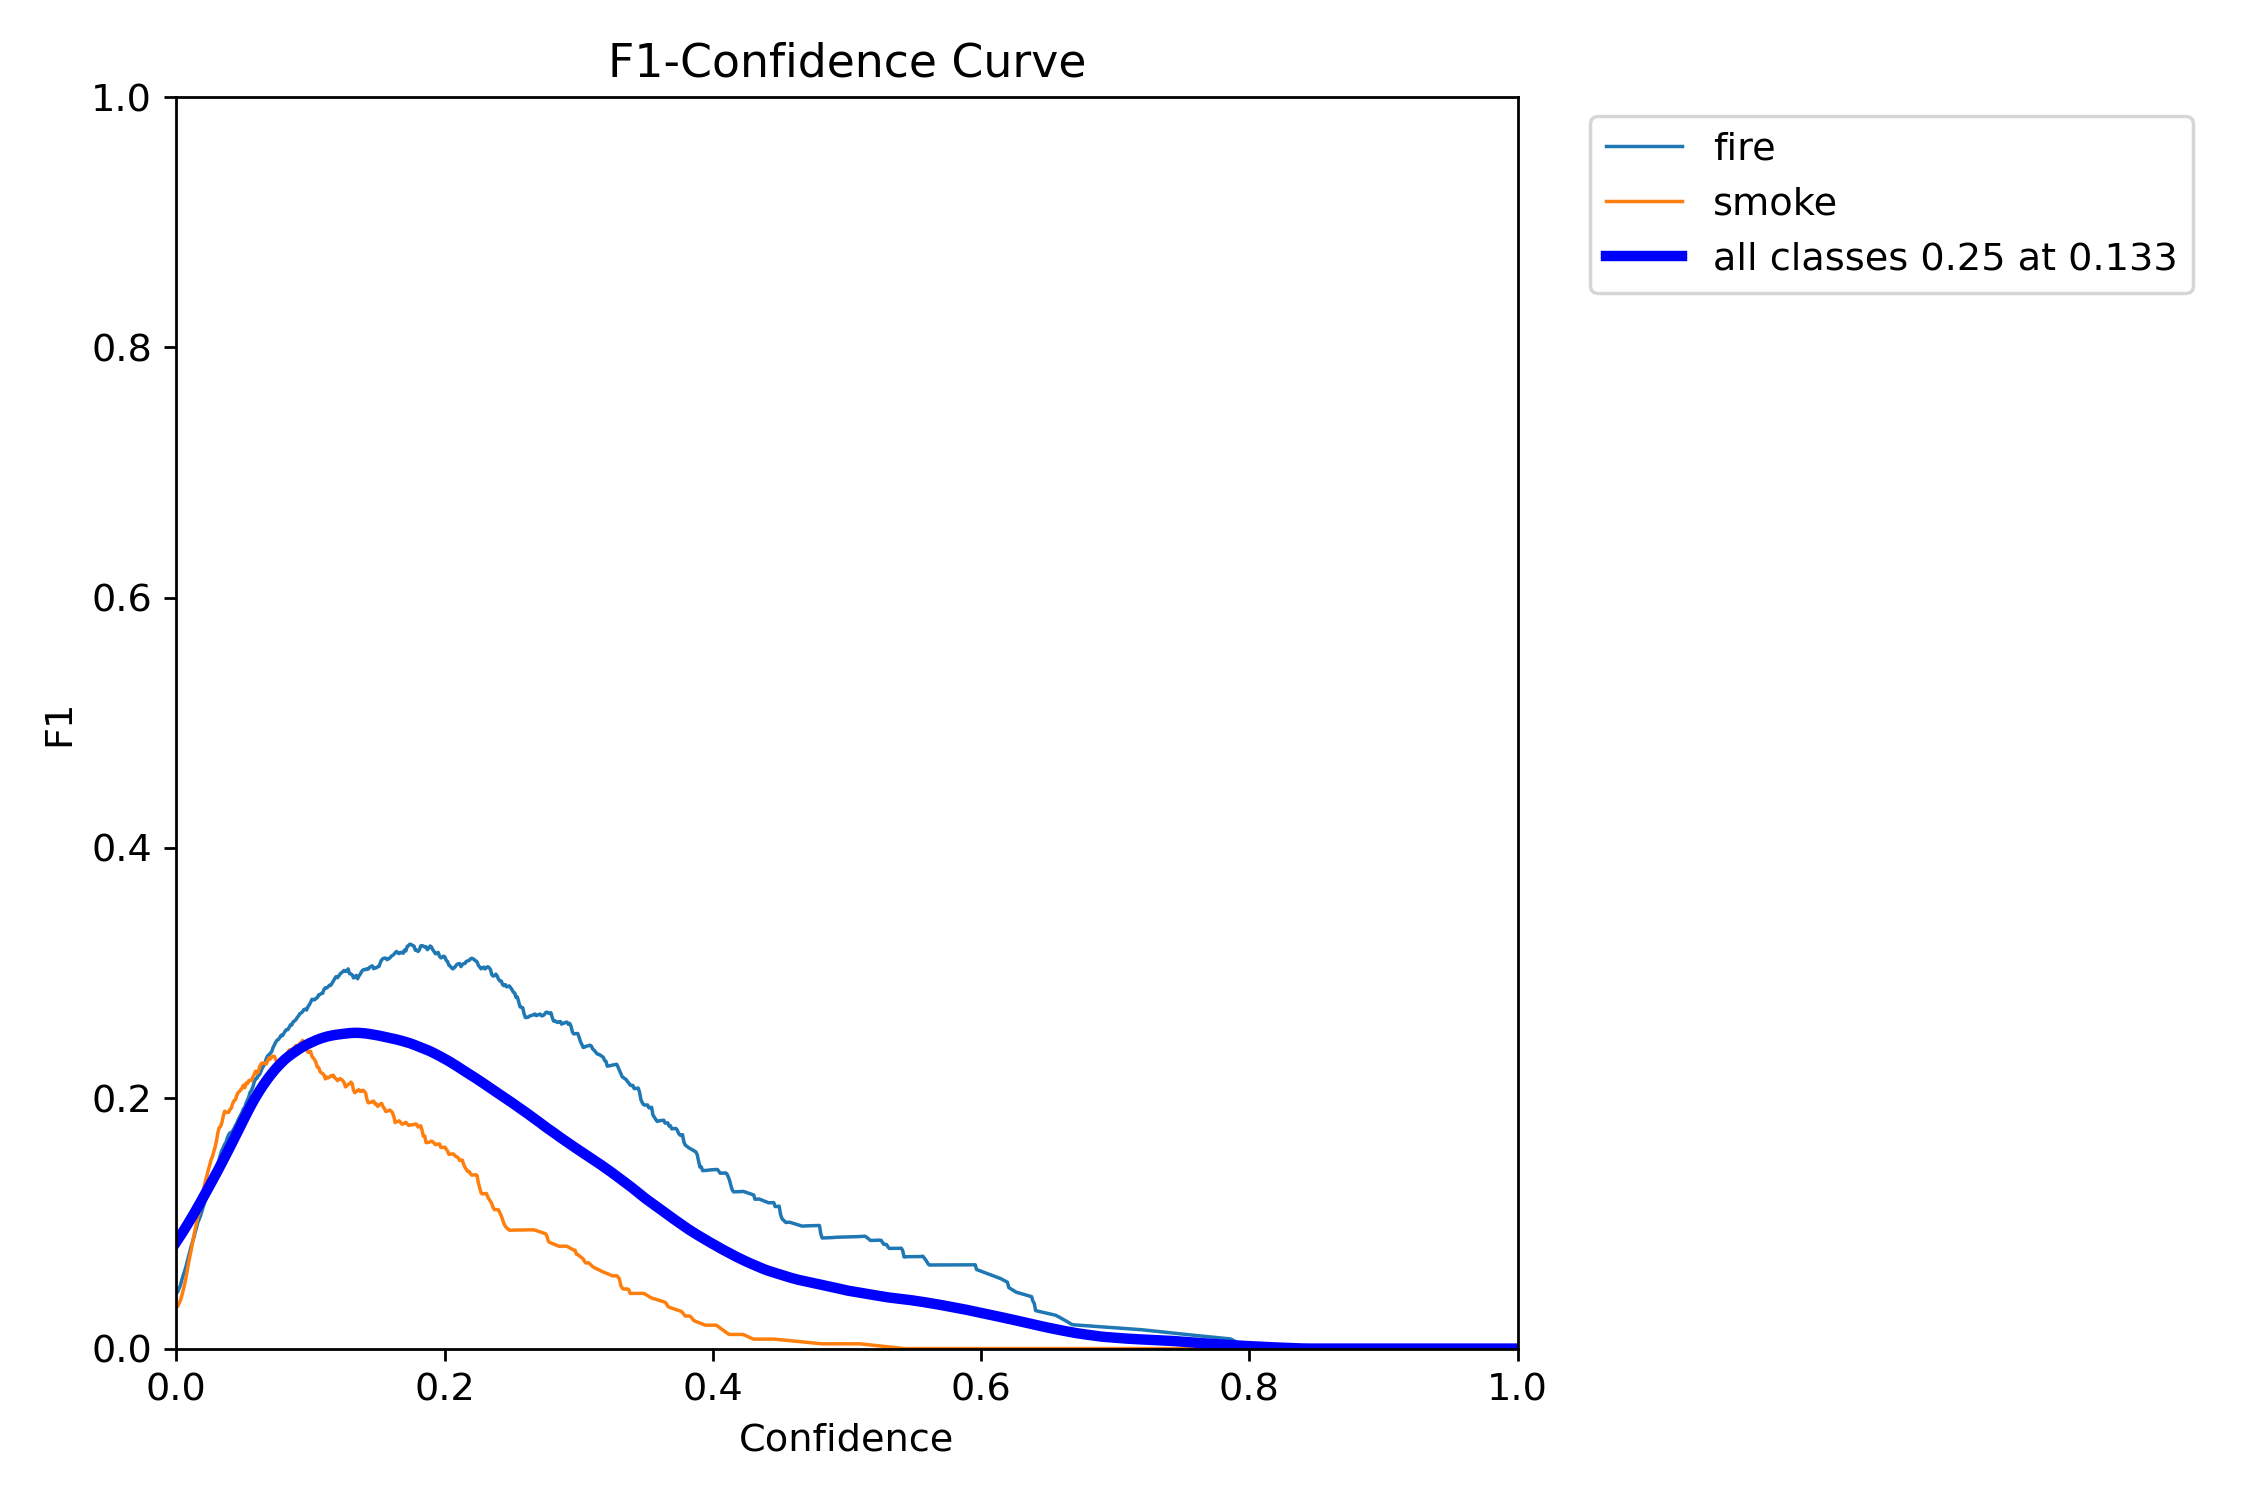

In [9]:
# Display F1 Curve
print("F1 Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/F1_curve.png'))

Precision-Recall Curve:


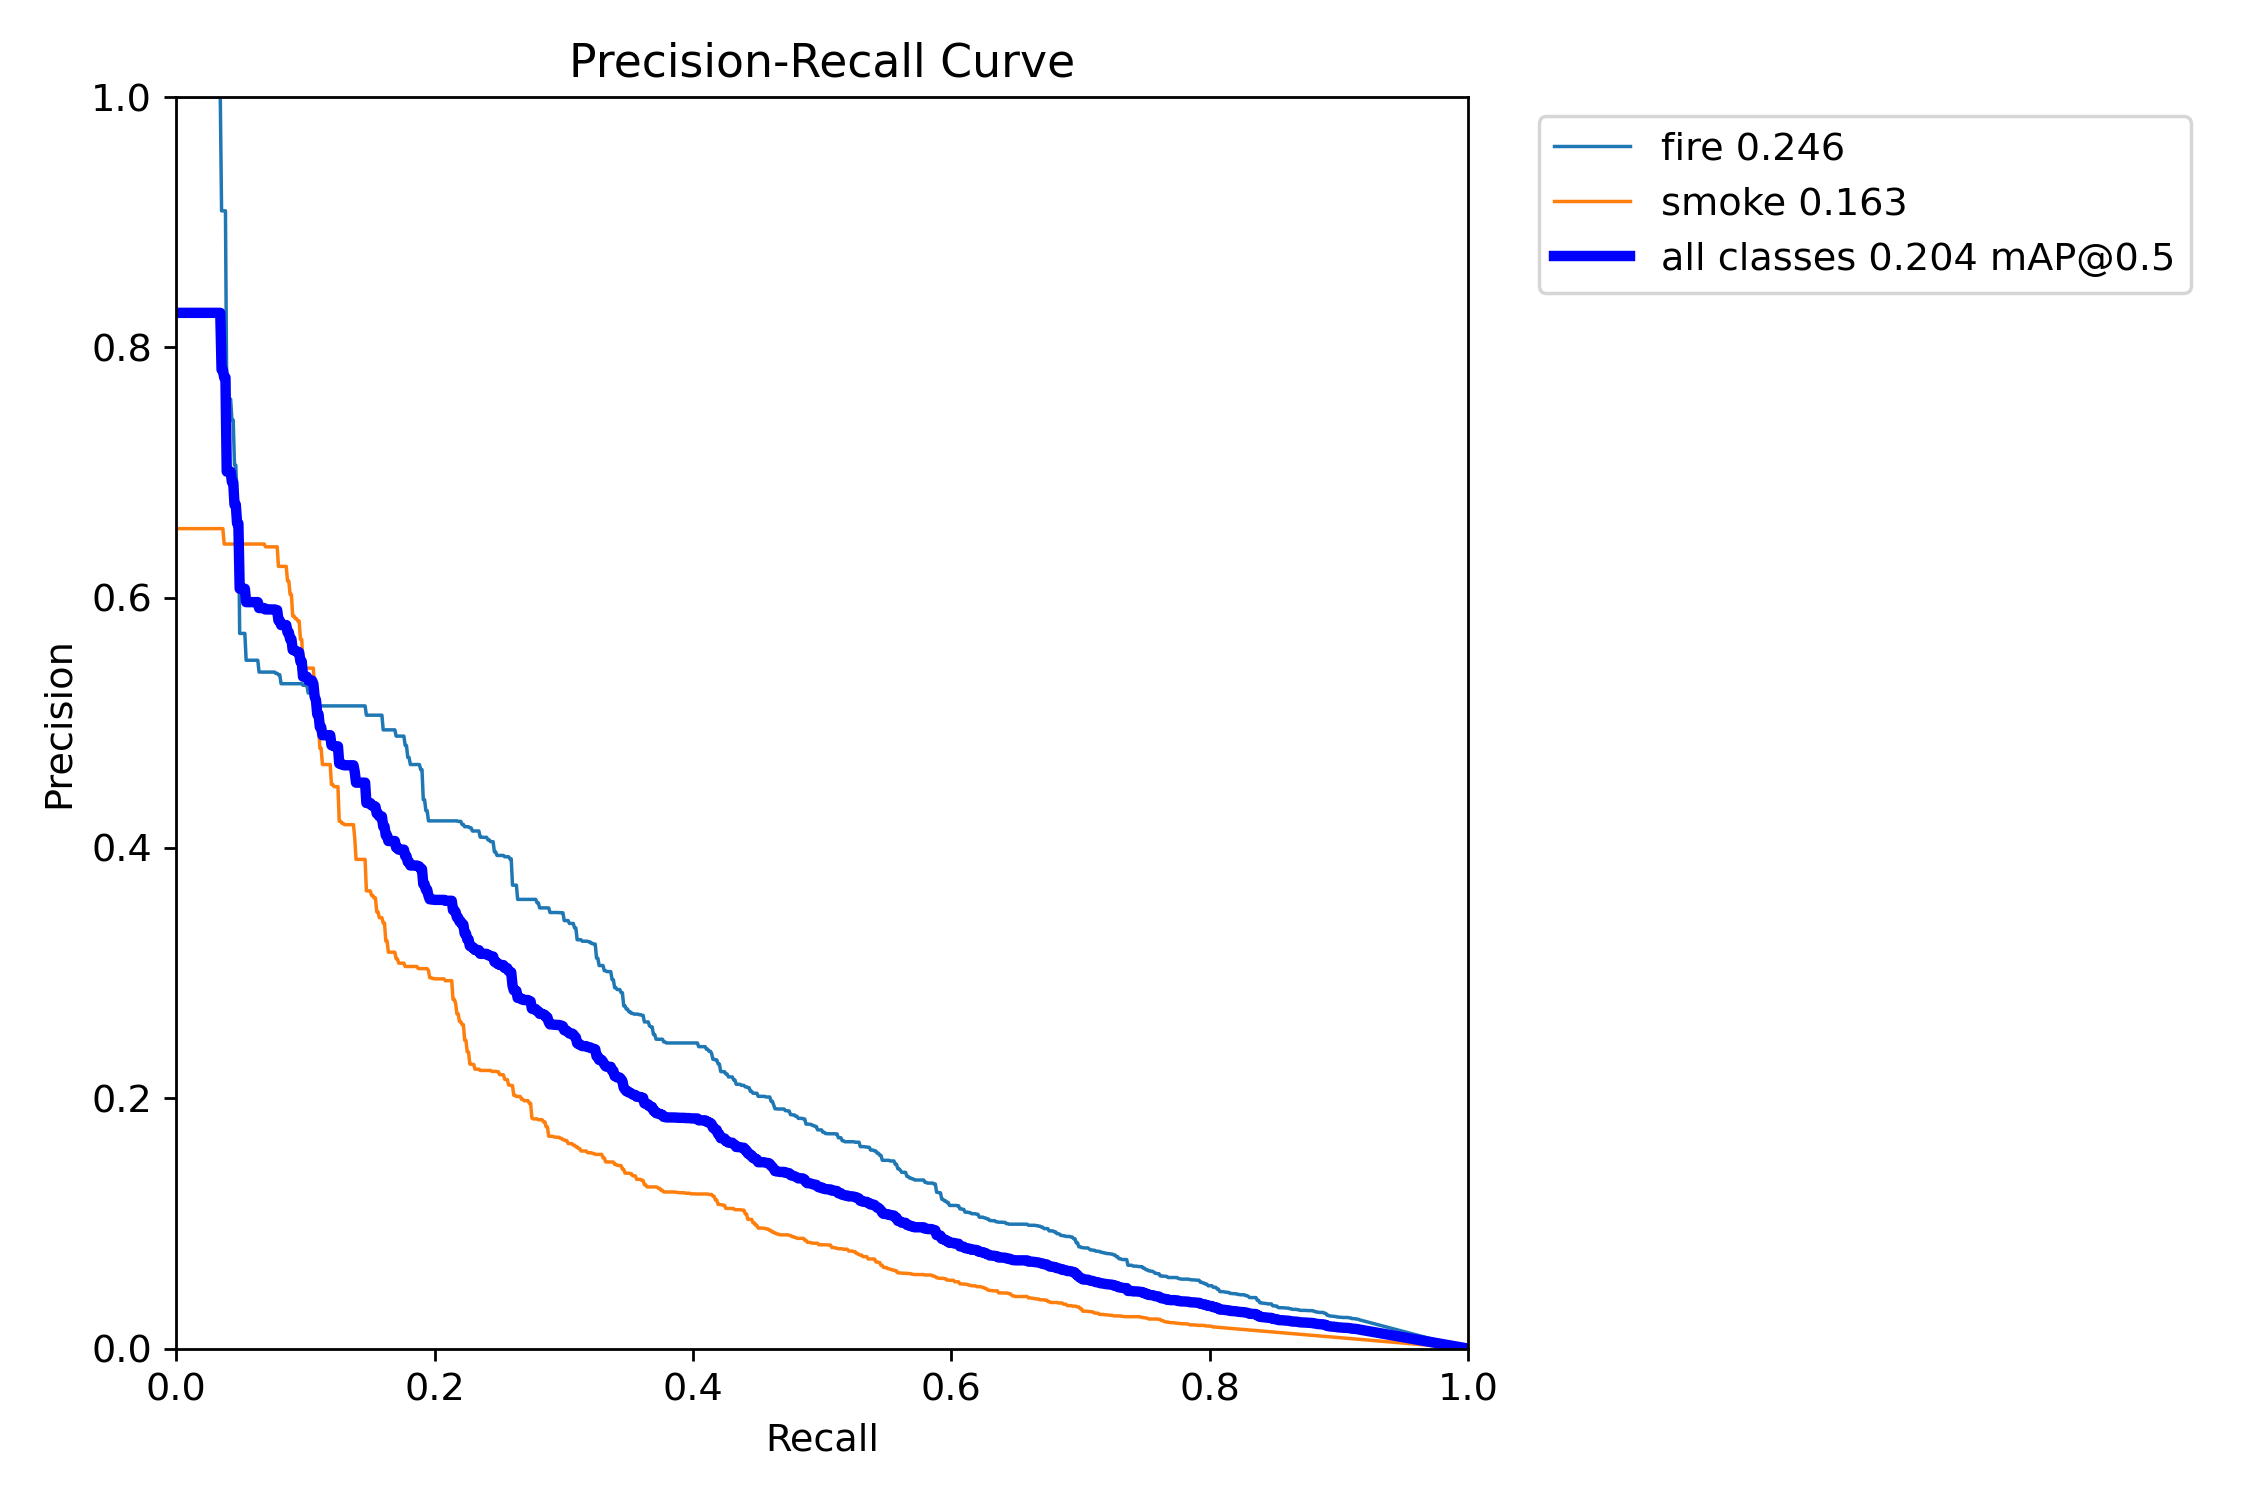

In [10]:
# Display PR Curve
print("Precision-Recall Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/PR_curve.png'))

Confusion Matrix:


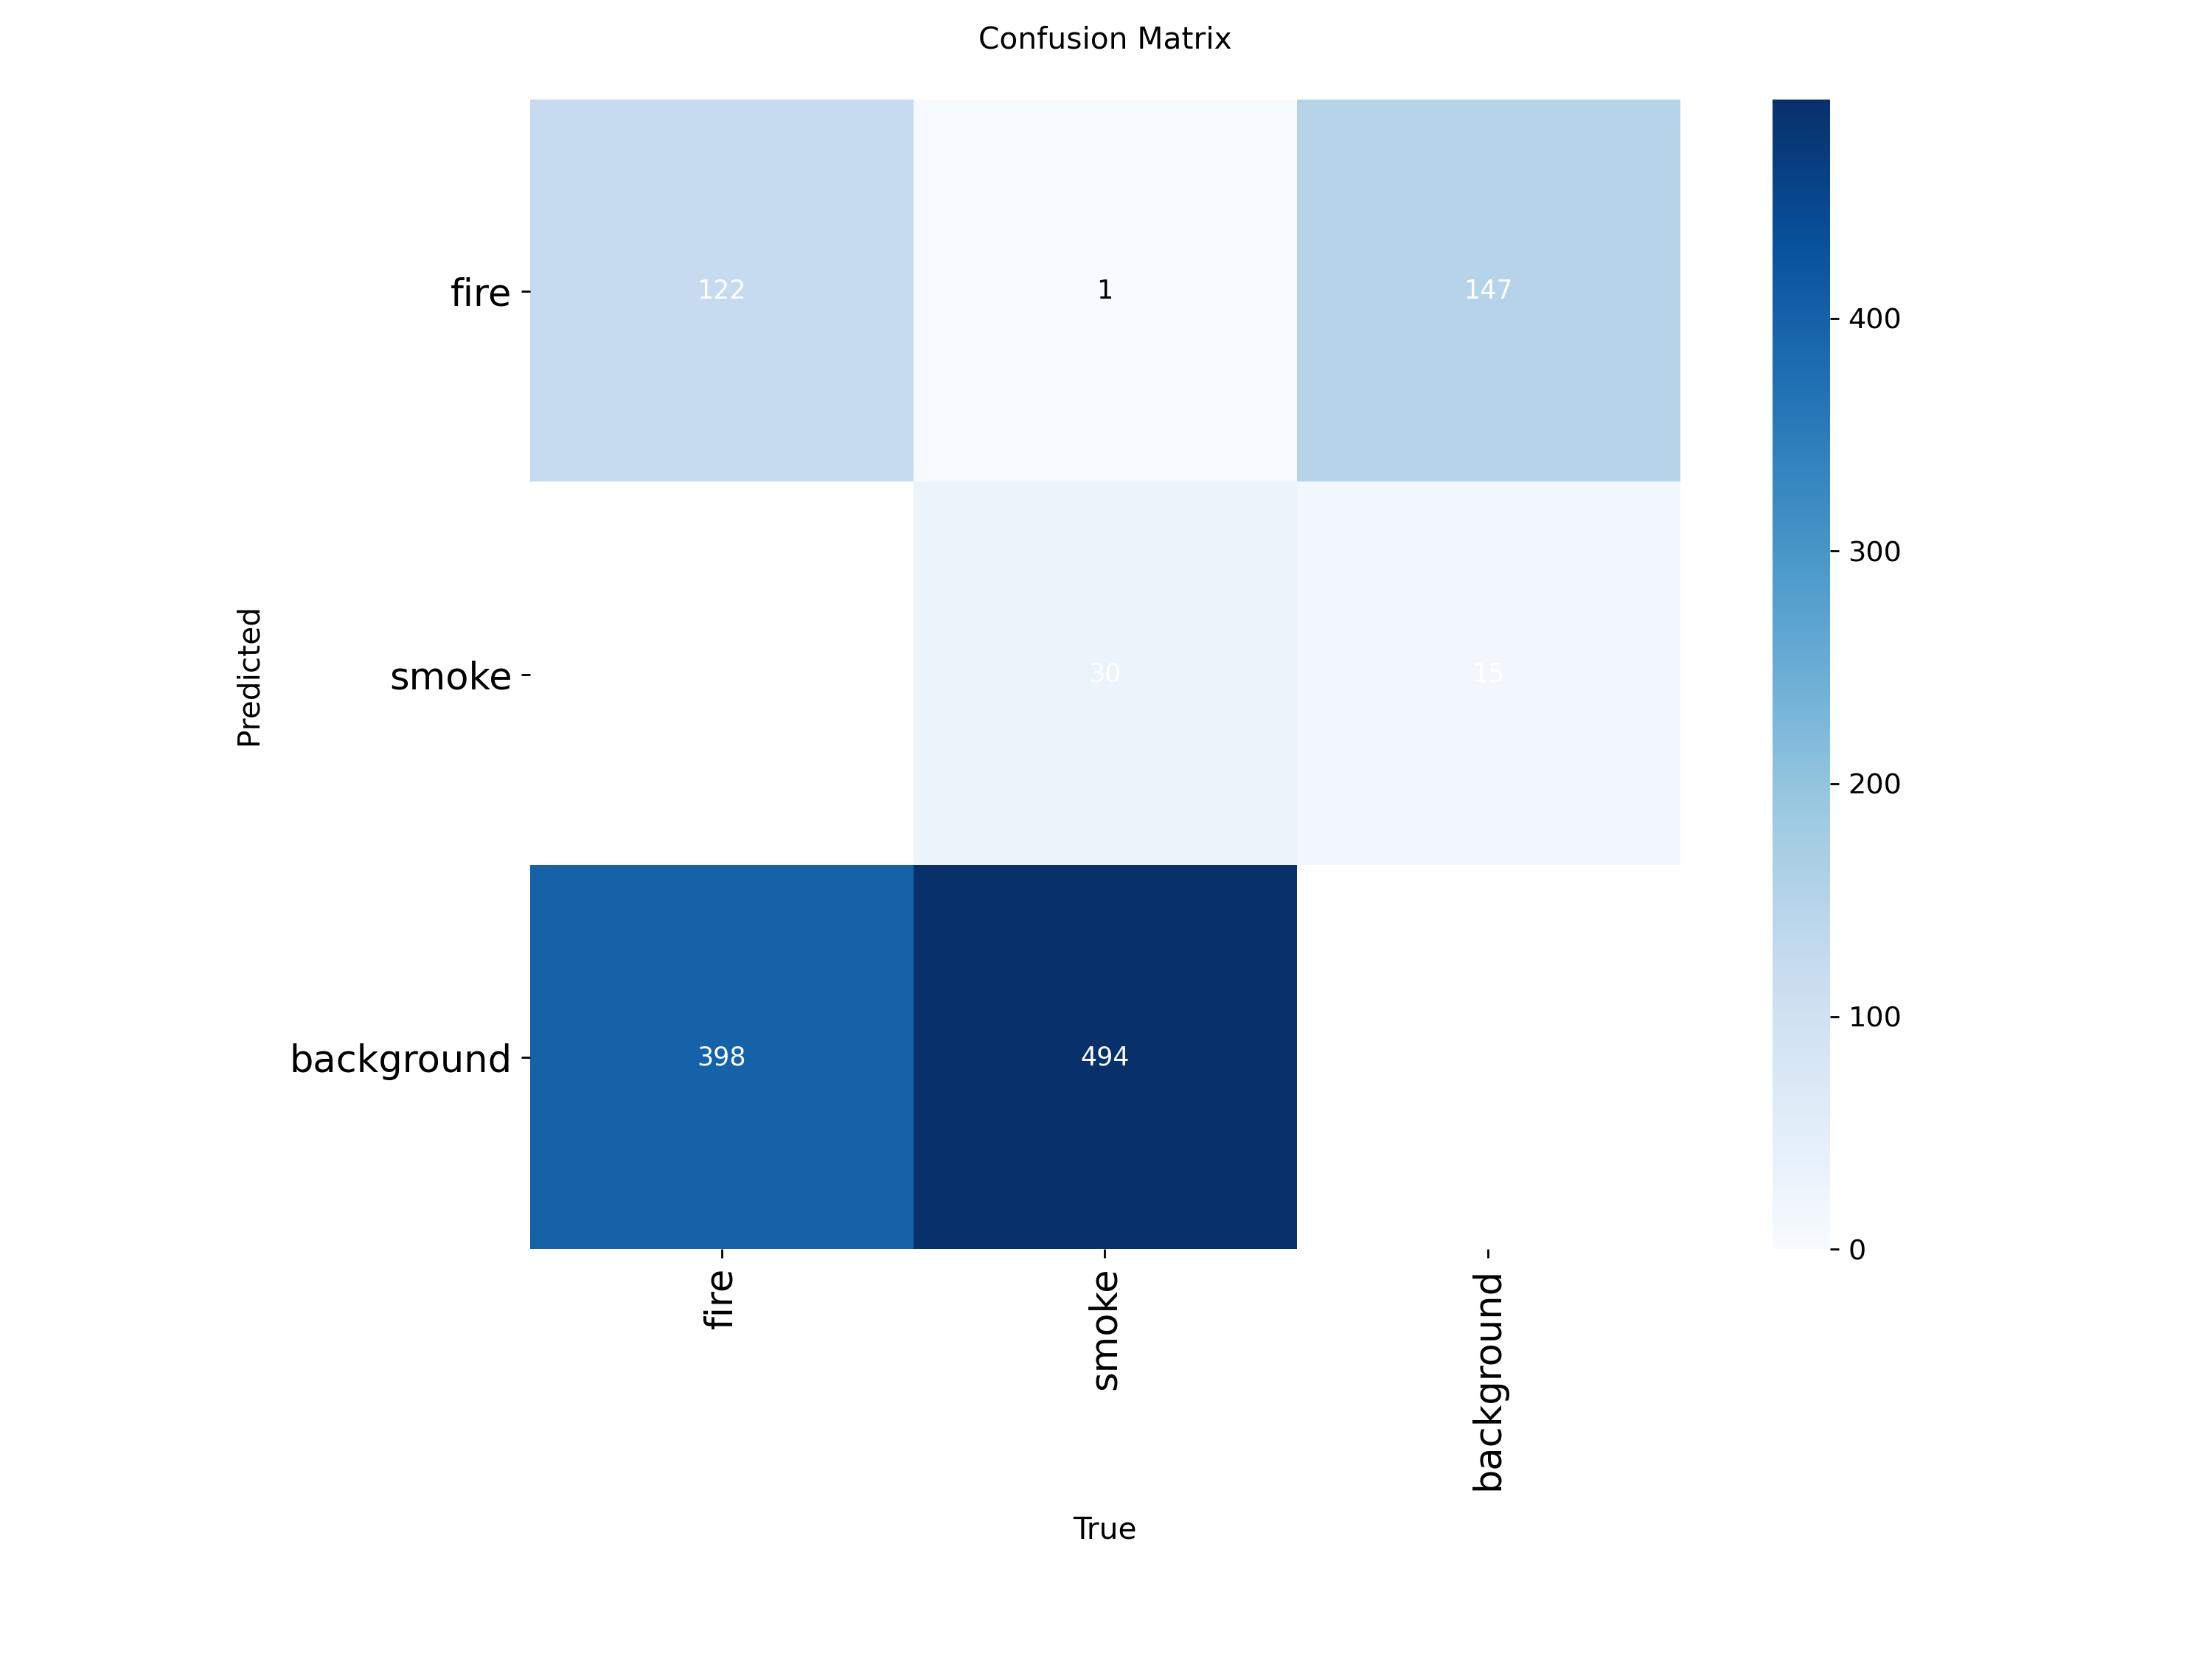

In [11]:
# Display Confusion Matrix
print("Confusion Matrix:")
display(Image(filename='/kaggle/working/runs/detect/train/confusion_matrix.png'))

Training Results:


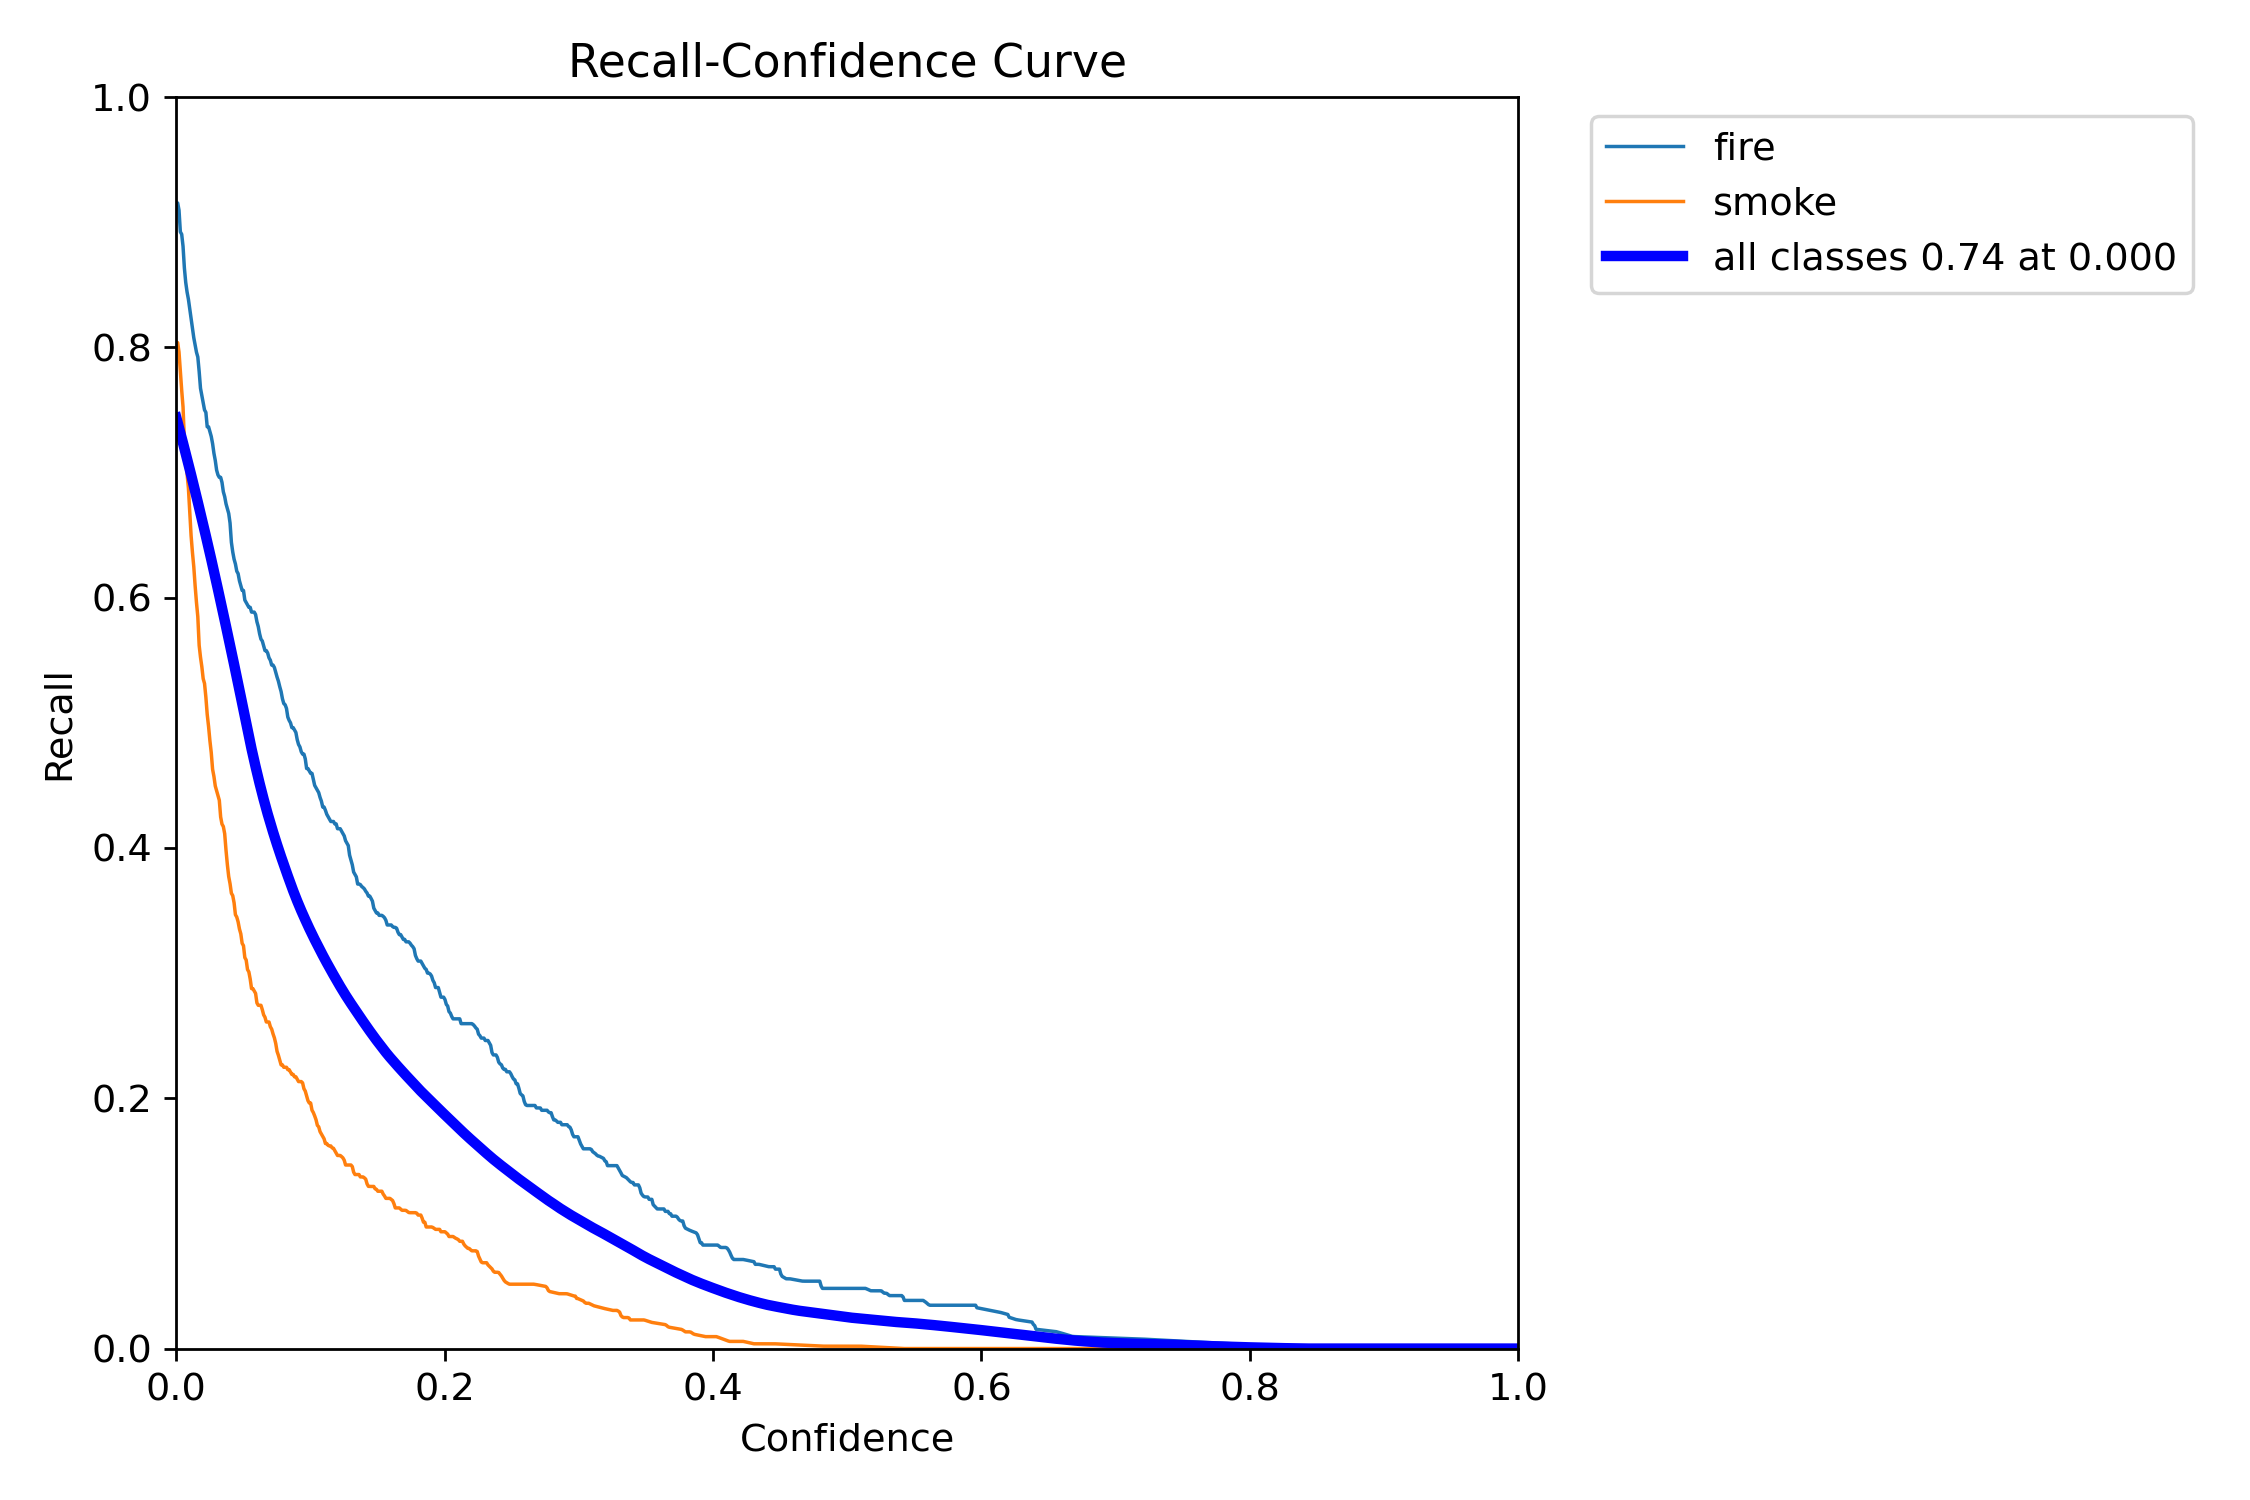

In [12]:
# Display Results (Metrics Over Epochs)
print("Training Results:")
display(Image(filename='/kaggle/working/runs/detect/train/R_curve.png'))

In [13]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forestfire13/fOREST-fire/images (2).jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forestfire13/fOREST-fire/images (2).jpg: 384x640 1 fire, 5 smokes, 8.5ms
Speed: 1.6ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Latency: 94.25 ms
